In [1]:
#importing 
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import numpy as np
import json
import pickle
import shutil
import os
import gc
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from datasets import Dataset as HFDataset
import evaluate
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)

C:\Users\Acer\OneDrive\Desktop\FRD model\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Device check ──────────────────────────────────────────────
USE_GPU = torch.cuda.is_available()
print(f"GPU available : {USE_GPU}")

# ── Disk space check ──────────────────────────────────────────
total, used, free = shutil.disk_usage("../")
print(f"Disk — Total: {total//(2**30)}GB | "
      f"Used: {used//(2**30)}GB | "
      f"Free: {free//(2**30)}GB")

GPU available : True
Disk — Total: 303GB | Used: 272GB | Free: 30GB


In [3]:
# ══════════════════════════════════════════════════════════════
# LOAD DATA
# ══════════════════════════════════════════════════════════════
syn_train  = pd.read_csv("../data/processed/syn_train.csv")
syn_val    = pd.read_csv("../data/processed/syn_val.csv")
syn_test   = pd.read_csv("../data/processed/syn_test.csv")

real_train = pd.read_csv("../data/processed/real_train.csv")
real_val   = pd.read_csv("../data/processed/real_val.csv")
real_test  = pd.read_csv("../data/processed/real_test.csv")

print(f"\n✅ Data loaded!")
print(f"   Syn  train/val/test : {len(syn_train)}/{len(syn_val)}/{len(syn_test)}")
print(f"   Real train/val/test : {len(real_train)}/{len(real_val)}/{len(real_test)}")


✅ Data loaded!
   Syn  train/val/test : 3579/447/448
   Real train/val/test : 1132/378/378


In [4]:
# ══════════════════════════════════════════════════════════════
# METRICS
# ══════════════════════════════════════════════════════════════
f1_metric  = evaluate.load("f1")
acc_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds          = np.argmax(logits, axis=1)
    return {
        "f1": f1_metric.compute(
            predictions=preds,
            references=labels,
            average="weighted"
        )["f1"],
        "accuracy": acc_metric.compute(
            predictions=preds,
            references=labels
        )["accuracy"],
    }

# ══════════════════════════════════════════════════════════════
# HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════
def to_hf_dataset(df):
    return HFDataset.from_dict({
        "review_text": df["review_text"].tolist(),
        "label":       df["label"].astype(int).tolist(),
    })

def evaluate_transformer(trainer, dataset, model_name,
                          phase, label_names=["genuine","fake"]):
    """Full evaluation with all visualizations"""

    predictions = trainer.predict(dataset)
    logits      = predictions.predictions
    labels      = predictions.label_ids
    probs       = torch.softmax(
        torch.tensor(logits), dim=1
    ).numpy()
    preds       = np.argmax(logits, axis=1)
    fake_probs  = probs[:, 1]

    title = f"{model_name} — {phase}"

    # Classification report
    print(f"\n{'='*50}")
    print(f"  {title} — Classification Report")
    print(f"{'='*50}")
    print(classification_report(
        labels, preds, target_names=label_names
    ))

    report = classification_report(
        labels, preds,
        target_names=label_names,
        output_dict=True
    )

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    # ── Confusion Matrix ──────────────────────────────────────
    cm = confusion_matrix(labels, preds)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=label_names,
        yticklabels=label_names,
        ax=axes[0, 0]
    )
    axes[0, 0].set_title("Confusion Matrix")
    axes[0, 0].set_ylabel("Actual")
    axes[0, 0].set_xlabel("Predicted")

    # ── Per-class Metrics ─────────────────────────────────────
    metrics     = ["precision", "recall", "f1-score"]
    genuine_val = [report["genuine"][m] for m in metrics]
    fake_val    = [report["fake"][m]    for m in metrics]
    x     = np.arange(len(metrics))
    width = 0.35
    axes[0, 1].bar(x - width/2, genuine_val, width,
                   label="Genuine", color="#4C72B0")
    axes[0, 1].bar(x + width/2, fake_val,    width,
                   label="Fake",    color="#DD8452")
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(metrics)
    axes[0, 1].set_ylim(0, 1.1)
    axes[0, 1].set_title("Per-class Metrics")
    axes[0, 1].legend()
    axes[0, 1].set_ylabel("Score")
    for i, (g, f) in enumerate(zip(genuine_val, fake_val)):
        axes[0, 1].text(i - width/2, g + 0.02,
                        f"{g:.2f}", ha="center", fontsize=9)
        axes[0, 1].text(i + width/2, f + 0.02,
                        f"{f:.2f}", ha="center", fontsize=9)

    # ── ROC Curve ─────────────────────────────────────────────
    fpr, tpr, _ = roc_curve(labels, fake_probs)
    roc_auc     = auc(fpr, tpr)
    axes[1, 0].plot(fpr, tpr, color="#2196F3", lw=2,
                    label=f"AUC = {roc_auc:.4f}")
    axes[1, 0].plot([0,1], [0,1], "k--", lw=1)
    axes[1, 0].set_xlim([0, 1])
    axes[1, 0].set_ylim([0, 1.05])
    axes[1, 0].set_xlabel("False Positive Rate")
    axes[1, 0].set_ylabel("True Positive Rate")
    axes[1, 0].set_title("ROC Curve")
    axes[1, 0].legend(loc="lower right")
    axes[1, 0].fill_between(fpr, tpr, alpha=0.1, color="#2196F3")

    # ── Precision-Recall Curve ────────────────────────────────
    precision, recall, _ = precision_recall_curve(labels, fake_probs)
    pr_auc = auc(recall, precision)
    axes[1, 1].plot(recall, precision, color="#4CAF50", lw=2,
                    label=f"PR-AUC = {pr_auc:.4f}")
    axes[1, 1].set_xlabel("Recall")
    axes[1, 1].set_ylabel("Precision")
    axes[1, 1].set_title("Precision-Recall Curve")
    axes[1, 1].legend(loc="upper right")
    axes[1, 1].fill_between(
        recall, precision, alpha=0.1, color="#4CAF50"
    )

    plt.tight_layout()
    os.makedirs("../results/figures", exist_ok=True)
    save_path = (f"../results/figures/"
                 f"{model_name}_{phase}_evaluation.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved → {save_path}")

    return {
        "accuracy":  report["accuracy"],
        "f1":        report["weighted avg"]["f1-score"],
        "precision": report["weighted avg"]["precision"],
        "recall":    report["weighted avg"]["recall"],
        "roc_auc":   roc_auc,
        "pr_auc":    pr_auc,
    }


def plot_training_history(log_history, model_name, phase):
    """Plot loss, f1, accuracy across epochs"""

    train_loss = [
        x["loss"] for x in log_history
        if "loss" in x and "eval_loss" not in x
    ]
    val_loss = [
        x["eval_loss"] for x in log_history
        if "eval_loss" in x
    ]
    val_f1 = [
        x["eval_f1"] for x in log_history
        if "eval_f1" in x
    ]
    val_acc = [
        x["eval_accuracy"] for x in log_history
        if "eval_accuracy" in x
    ]

    epochs_train = range(1, len(train_loss) + 1)
    epochs_val   = range(1, len(val_loss)   + 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(
        f"{model_name} — {phase} Training History",
        fontsize=13, fontweight="bold"
    )

    axes[0].plot(epochs_train, train_loss,
                 label="Train", color="#F44336")
    axes[0].plot(epochs_val,   val_loss,
                 label="Val",   color="#2196F3")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(epochs_val, val_f1,
                 color="#4CAF50", marker="o")
    axes[1].set_title("Val F1")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylim(0, 1)

    axes[2].plot(epochs_val, val_acc,
                 color="#FF9800", marker="s")
    axes[2].set_title("Val Accuracy")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylim(0, 1)

    plt.tight_layout()
    os.makedirs("../results/figures", exist_ok=True)
    save_path = (f"../results/figures/"
                 f"{model_name}_{phase}_history.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved → {save_path}")


def plot_model_comparison(all_results):
    """Compare all models pretrain vs finetune"""

    model_names = list(all_results.keys())
    metrics     = ["accuracy", "f1", "roc_auc", "pr_auc"]

    fig, axes = plt.subplots(1, 4, figsize=(18, 5))
    fig.suptitle(
        "Transformer Models — Pretrain vs Finetune",
        fontsize=13, fontweight="bold"
    )

    for i, metric in enumerate(metrics):
        pre_vals = [
            all_results[m]["pretrain"].get(metric, 0)
            for m in model_names
        ]
        ft_vals = [
            all_results[m]["finetune"].get(metric, 0)
            for m in model_names
        ]
        x     = np.arange(len(model_names))
        width = 0.35
        axes[i].bar(x - width/2, pre_vals, width,
                    label="Pretrain", color="#5C85D6", alpha=0.85)
        axes[i].bar(x + width/2, ft_vals,  width,
                    label="Finetune", color="#E8845A", alpha=0.85)
        axes[i].set_xticks(x)
        axes[i].set_xticklabels(model_names, rotation=15)
        axes[i].set_title(metric.upper())
        axes[i].set_ylim(0, 1.1)
        axes[i].legend()
        for j, (p, f) in enumerate(zip(pre_vals, ft_vals)):
            axes[i].text(j - width/2, p + 0.02,
                         f"{p:.2f}", ha="center", fontsize=8)
            axes[i].text(j + width/2, f + 0.02,
                         f"{f:.2f}", ha="center", fontsize=8)

    plt.tight_layout()
    save_path = "../results/figures/transformer_comparison.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved → {save_path}")


def cleanup(model_name):
    """Free memory and disk space between models"""
    # Delete checkpoint folders to free disk
    for folder in [
        f"../models/transformers/{model_name}_pretrain_ckpt",
        f"../models/transformers/{model_name}_finetune_ckpt",
    ]:
        if os.path.exists(folder):
            shutil.rmtree(folder)
            print(f"🗑️  Deleted {folder}")

    gc.collect()
    if USE_GPU:
        torch.cuda.empty_cache()

    total, used, free = shutil.disk_usage("../")
    print(f"💾 Free disk : {free//(2**30)}GB")


print("✅ All functions defined — ready to train!")

# ══════════════════════════════════════════════════════════════
# MODELS
# ══════════════════════════════════════════════════════════════
MODELS = {
    "mBERT":       "bert-base-multilingual-cased",
    "XLM_RoBERTa": "xlm-roberta-base",
}

all_results = {}

✅ All functions defined — ready to train!



  MODEL : mBERT
  CKPT  : bert-base-multilingual-cased



Tokenizing datasets...


Map: 100%|██████████████████████████████████████████████████████████████████| 378/378 [00:00<00:00, 7659.42 examples/s]


✅ Tokenization complete!

--- PHASE 1: PRETRAIN (mBERT) ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 199/199 [00:00<00:00, 3326.13it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newl

Starting pretraining...


Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.121339,0.118645,0.973146,0.973154
2,0.057685,0.042645,0.991050,0.991051
3,0.032956,0.039537,0.993289,0.993289
4,0.013746,0.093708,0.986578,0.986577
5,0.003326,0.043404,0.993289,0.993289
6,0.000085,0.047333,0.991052,0.991051
7,0.000061,0.052991,0.991052,0.991051
8,0.000051,0.055551,0.991052,0.991051
9,0.000046,0.056778,0.991052,0.991051
10,0.000130,0.065119,0.991052,0.991051


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.72s/it]


✅ Pretrained model saved → ../models/transformers/mBERT_pretrained


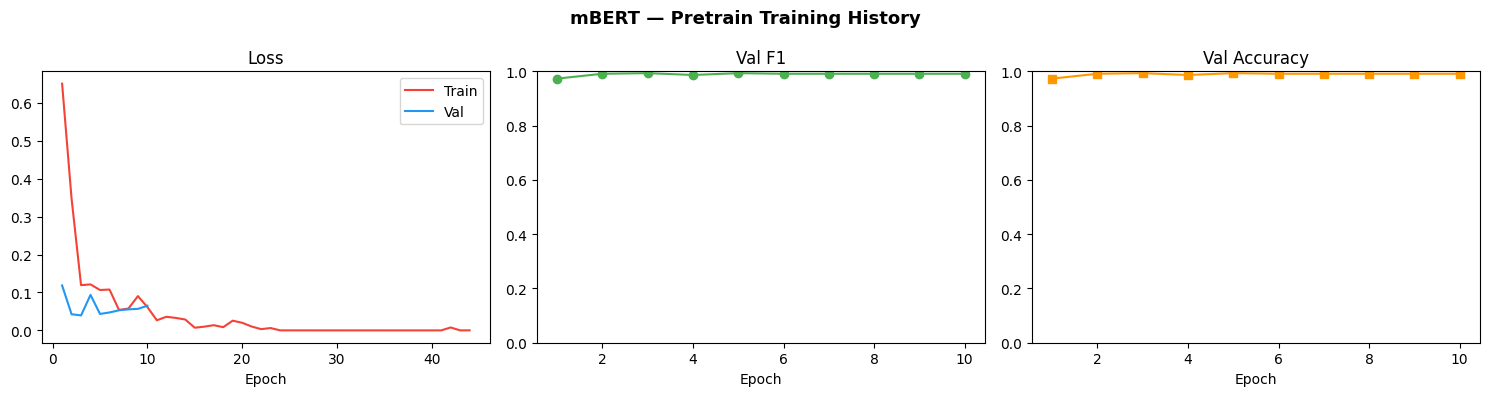

✅ Saved → ../results/figures/mBERT_Pretrain_history.png

--- mBERT Pretrain Test Results ---



  mBERT — Pretrain — Classification Report
              precision    recall  f1-score   support

     genuine       1.00      1.00      1.00       219
        fake       1.00      1.00      1.00       229

    accuracy                           1.00       448
   macro avg       1.00      1.00      1.00       448
weighted avg       1.00      1.00      1.00       448



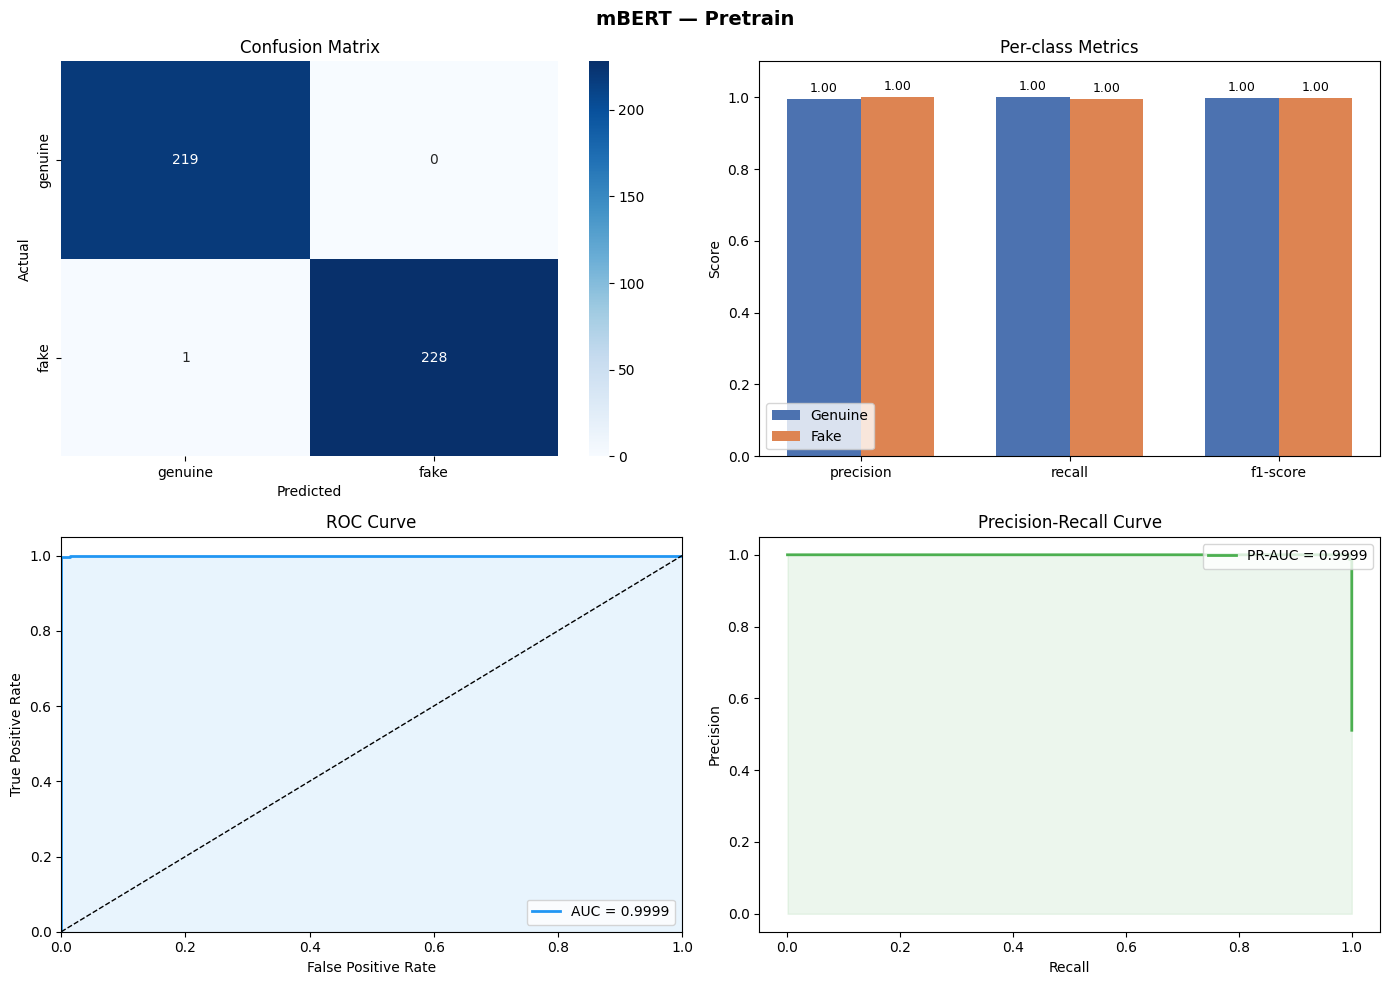

✅ Saved → ../results/figures/mBERT_Pretrain_evaluation.png

  Accuracy : 0.9978
  F1       : 0.9978
  ROC-AUC  : 0.9999

--- PHASE 2: FINETUNE (mBERT) ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 3726.85it/s]
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting finetuning...


Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.085960,0.160177,0.960272,0.960317
2,0.014456,0.090921,0.986772,0.986772
3,0.042546,0.050740,0.986773,0.986772
4,0.000089,0.063141,0.989418,0.989418
5,0.000071,0.067627,0.989418,0.989418


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.60s/it]


✅ Finetuned model saved → ../models/transformers/mBERT_finetuned


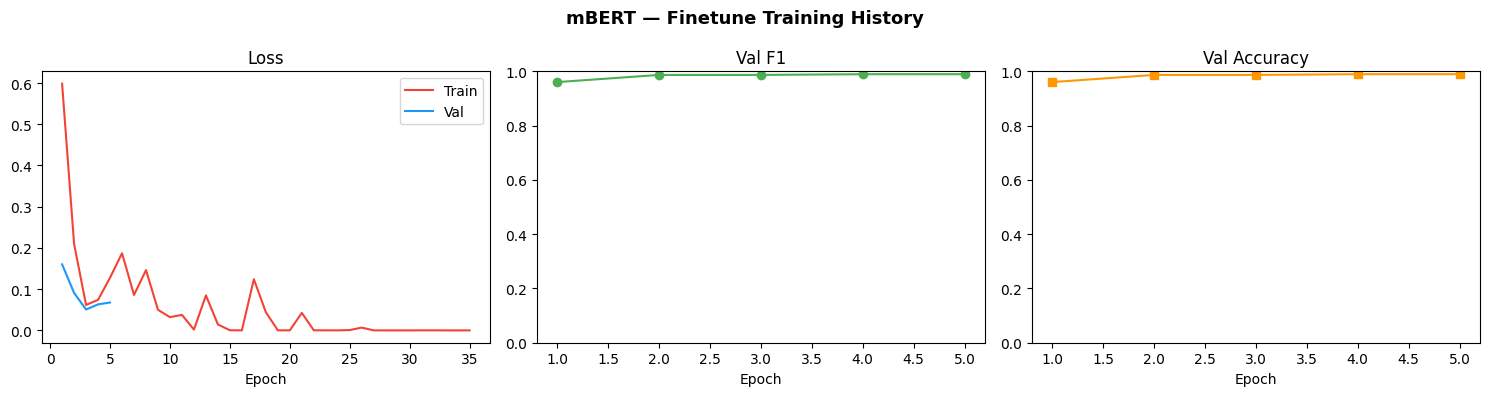

✅ Saved → ../results/figures/mBERT_Finetune_history.png

--- mBERT Finetune Test Results ---



  mBERT — Finetune — Classification Report
              precision    recall  f1-score   support

     genuine       1.00      0.98      0.99       191
        fake       0.98      1.00      0.99       187

    accuracy                           0.99       378
   macro avg       0.99      0.99      0.99       378
weighted avg       0.99      0.99      0.99       378



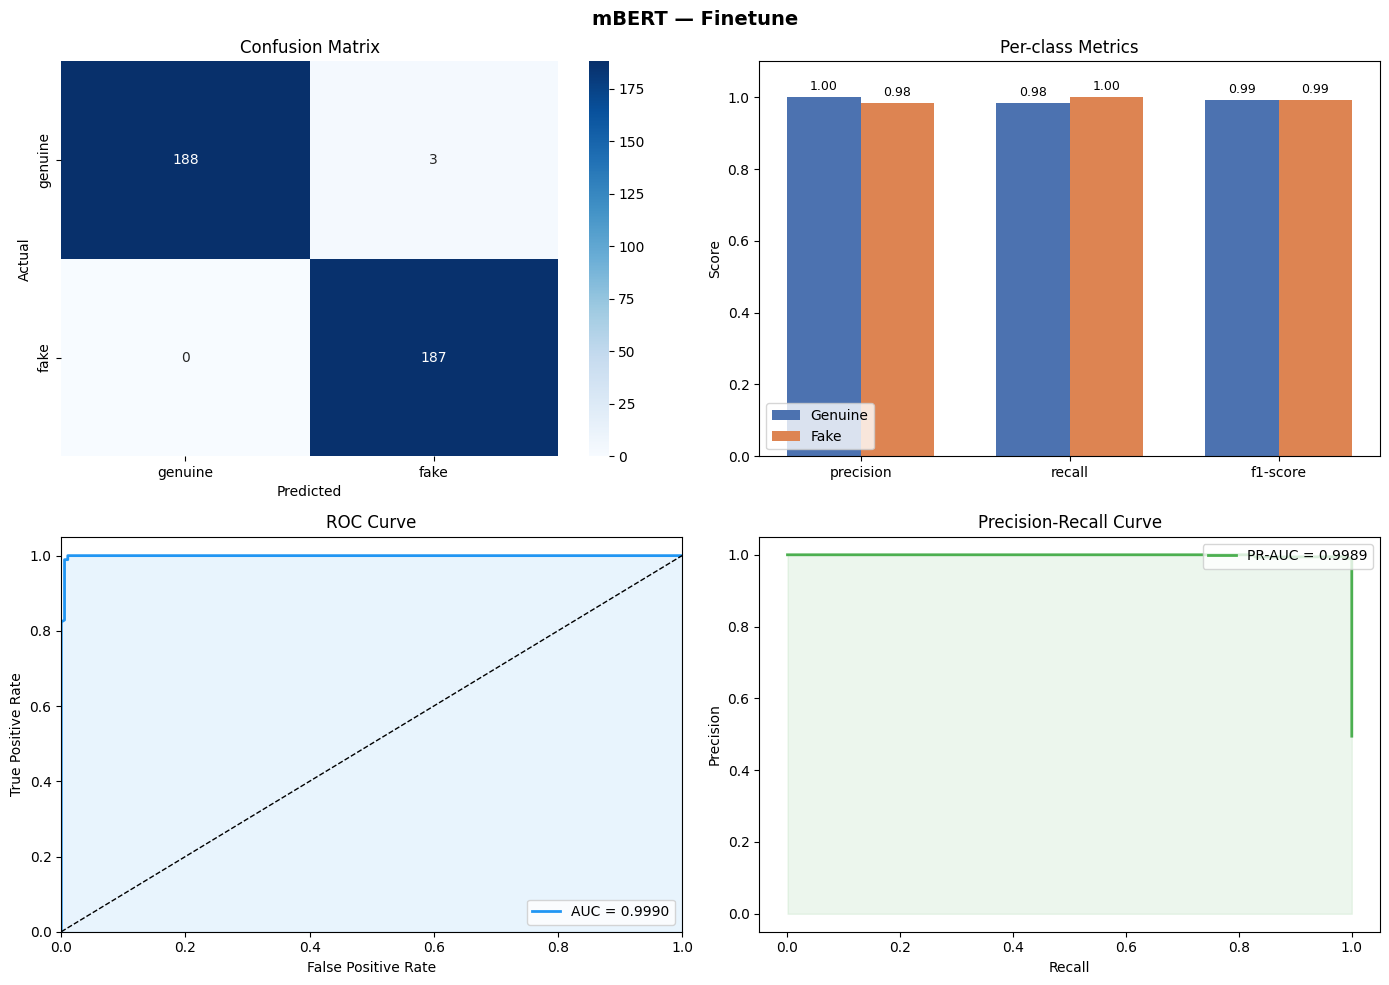

✅ Saved → ../results/figures/mBERT_Finetune_evaluation.png

  Accuracy : 0.9921
  F1       : 0.9921
  ROC-AUC  : 0.9990
🗑️  Deleted ../models/transformers/mBERT_pretrain_ckpt
🗑️  Deleted ../models/transformers/mBERT_finetune_ckpt
💾 Free disk : 28GB

✅ mBERT complete!

  MODEL : XLM_RoBERTa
  CKPT  : xlm-roberta-base

Tokenizing datasets...


Map: 100%|██████████████████████████████████████████████████████████████████| 378/378 [00:00<00:00, 8706.27 examples/s]


✅ Tokenization complete!

--- PHASE 1: PRETRAIN (XLM_RoBERTa) ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 197/197 [00:00<00:00, 2564.65it/s]
XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downst

Starting pretraining...


Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.200960,0.241793,0.952990,0.953020
2,0.125239,0.147386,0.973158,0.973154
3,0.084122,0.052988,0.988815,0.988814
4,0.045192,0.037137,0.993289,0.993289
5,0.009726,0.053329,0.993288,0.993289
6,0.034719,0.044715,0.993289,0.993289
7,0.025648,0.044591,0.993289,0.993289
8,0.012283,0.047748,0.993289,0.993289
9,0.000211,0.039377,0.995526,0.995526
10,0.000140,0.041218,0.995526,0.995526


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.25s/it]


✅ Pretrained model saved → ../models/transformers/XLM_RoBERTa_pretrained


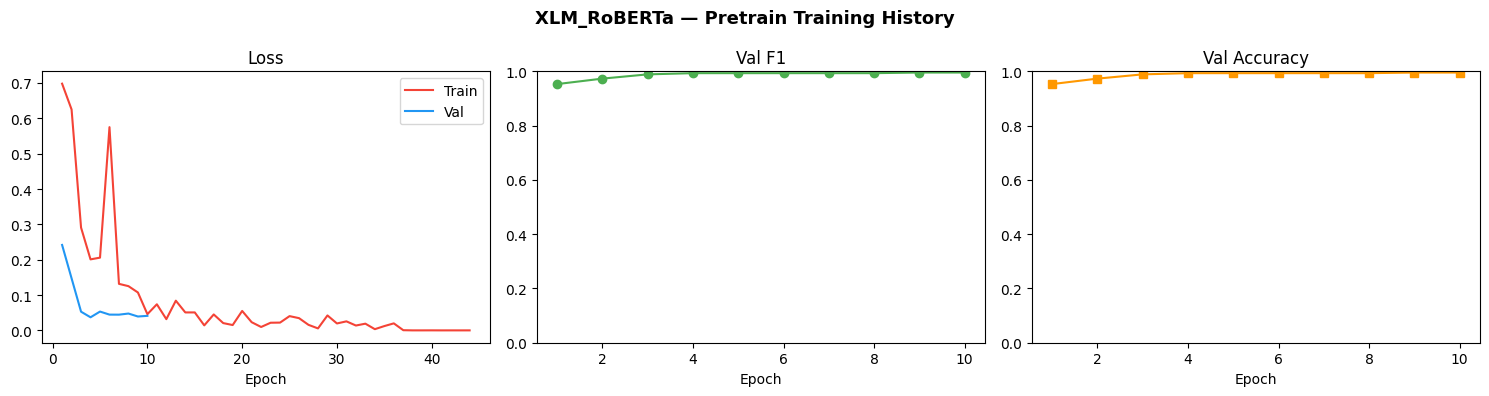

✅ Saved → ../results/figures/XLM_RoBERTa_Pretrain_history.png

--- XLM_RoBERTa Pretrain Test Results ---



  XLM_RoBERTa — Pretrain — Classification Report
              precision    recall  f1-score   support

     genuine       0.99      1.00      1.00       219
        fake       1.00      0.99      1.00       229

    accuracy                           1.00       448
   macro avg       1.00      1.00      1.00       448
weighted avg       1.00      1.00      1.00       448



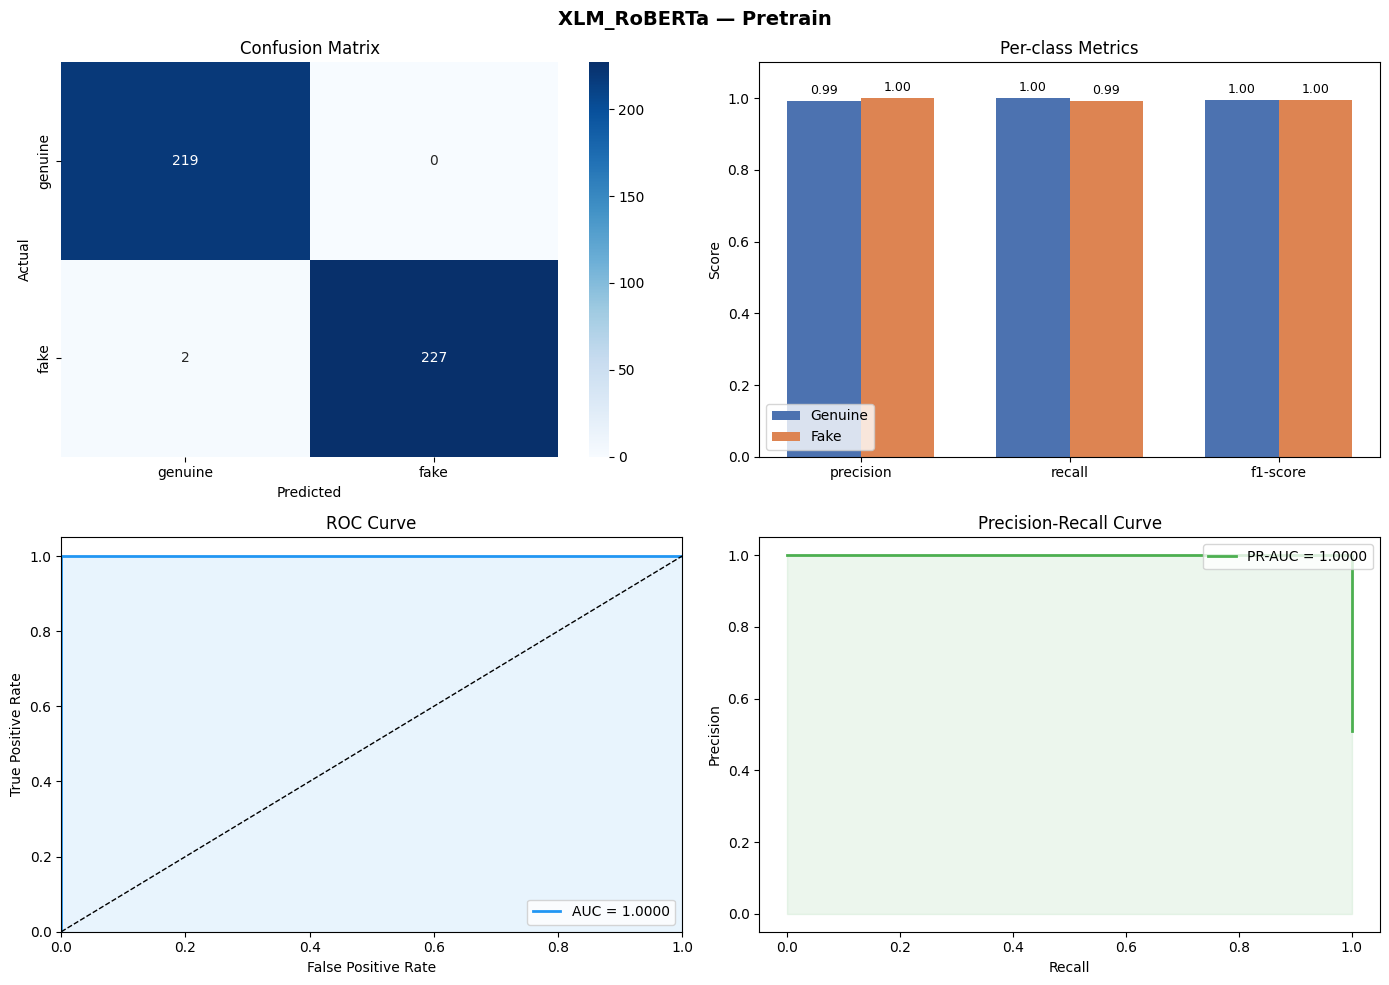

✅ Saved → ../results/figures/XLM_RoBERTa_Pretrain_evaluation.png

  Accuracy : 0.9955
  F1       : 0.9955
  ROC-AUC  : 1.0000

--- PHASE 2: FINETUNE (XLM_RoBERTa) ---


Loading weights: 100%|█████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 3924.07it/s]
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Starting finetuning...


Epoch,Training Loss,Validation Loss,F1,Accuracy
1,0.094327,0.223717,0.960285,0.960317
2,0.093663,0.084120,0.984127,0.984127
3,0.037399,0.081603,0.986768,0.986772
4,0.000226,0.147993,0.981481,0.981481
5,0.000173,0.103271,0.984127,0.984127


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:02<00:00,  2.26s/it]


✅ Finetuned model saved → ../models/transformers/XLM_RoBERTa_finetuned


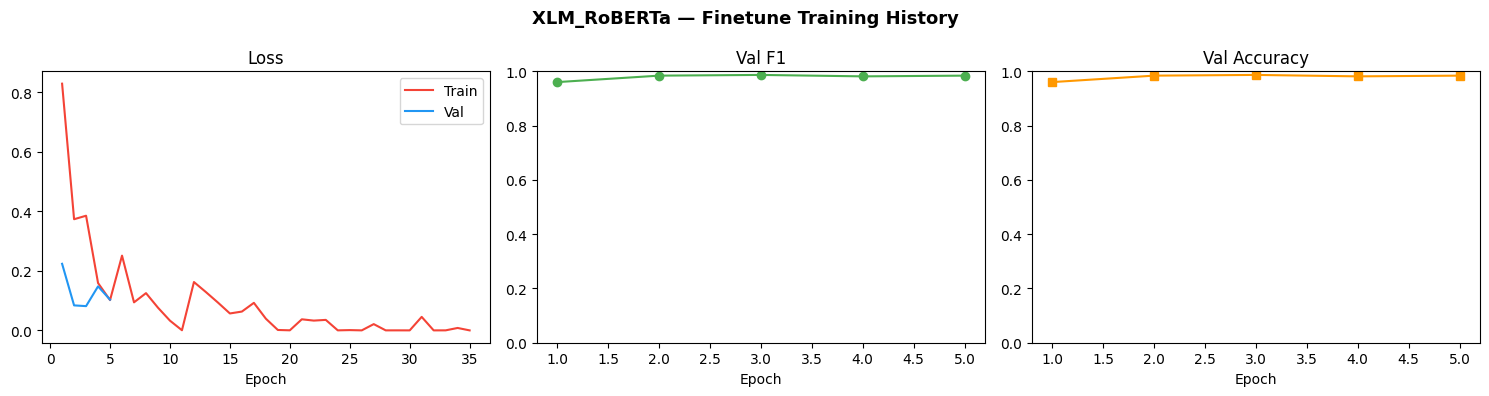

✅ Saved → ../results/figures/XLM_RoBERTa_Finetune_history.png

--- XLM_RoBERTa Finetune Test Results ---



  XLM_RoBERTa — Finetune — Classification Report
              precision    recall  f1-score   support

     genuine       0.99      0.98      0.99       191
        fake       0.98      0.99      0.99       187

    accuracy                           0.99       378
   macro avg       0.99      0.99      0.99       378
weighted avg       0.99      0.99      0.99       378



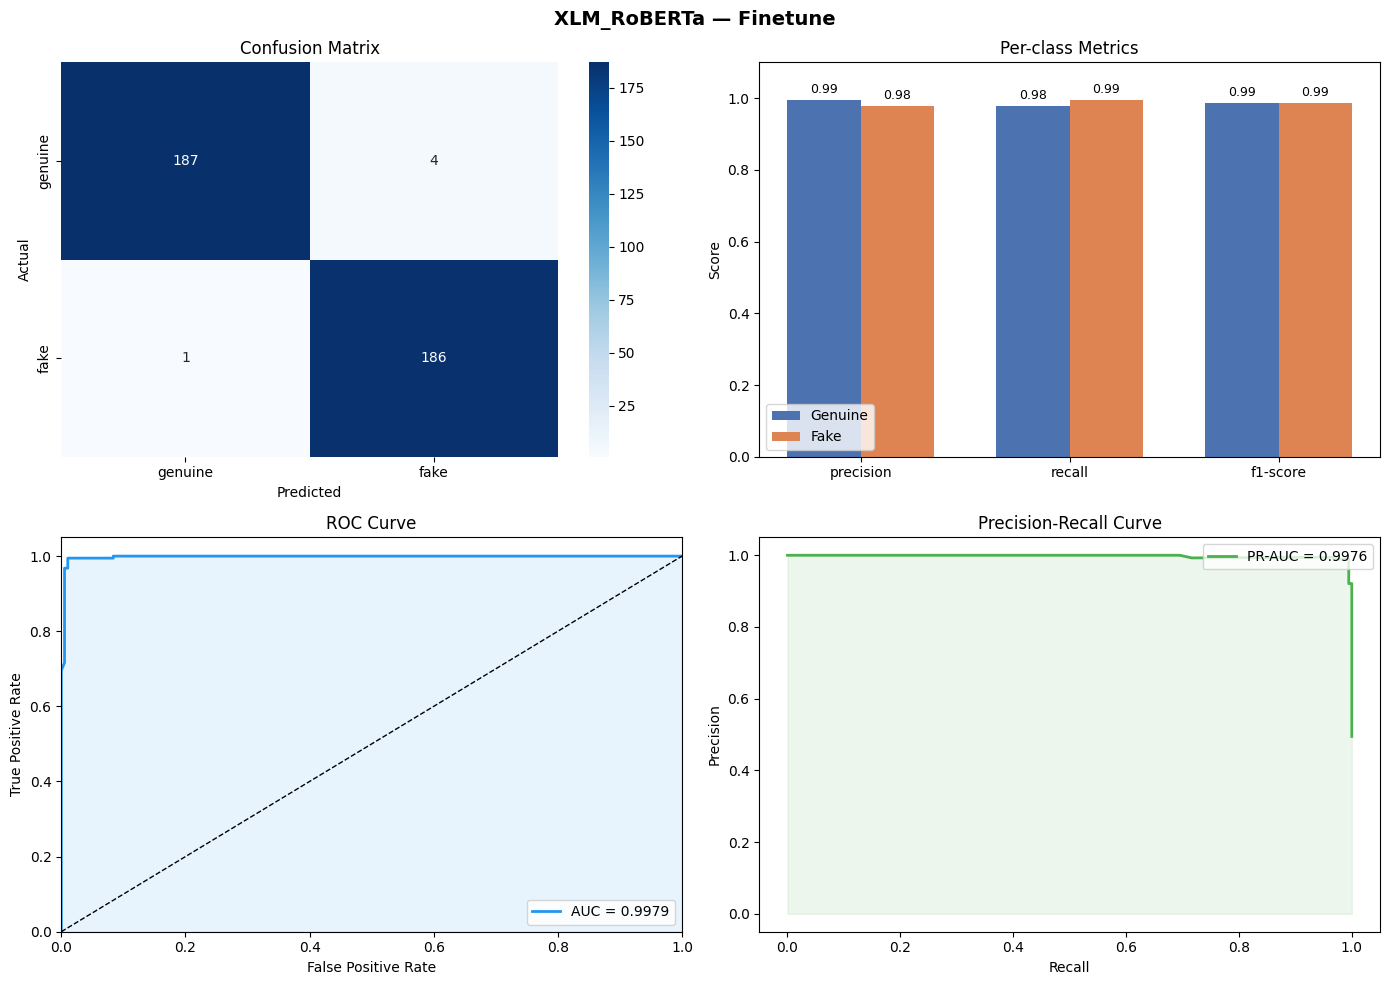

✅ Saved → ../results/figures/XLM_RoBERTa_Finetune_evaluation.png

  Accuracy : 0.9868
  F1       : 0.9868
  ROC-AUC  : 0.9979
🗑️  Deleted ../models/transformers/XLM_RoBERTa_pretrain_ckpt
🗑️  Deleted ../models/transformers/XLM_RoBERTa_finetune_ckpt
💾 Free disk : 26GB

✅ XLM_RoBERTa complete!


In [5]:
# ══════════════════════════════════════════════════════════════
# MAIN TRAINING LOOP
# ══════════════════════════════════════════════════════════════
for model_name, model_checkpoint in MODELS.items():
    print(f"\n{'='*55}")
    print(f"  MODEL : {model_name}")
    print(f"  CKPT  : {model_checkpoint}")
    print(f"{'='*55}")

    all_results[model_name] = {}

    # ── Create output dirs ────────────────────────────────────
    os.makedirs("../models/transformers", exist_ok=True)
    os.makedirs("../results/figures",     exist_ok=True)
    os.makedirs("../results/metrics",     exist_ok=True)
    os.makedirs(f"../results/logs/{model_name}_pretrain", exist_ok=True)
    os.makedirs(f"../results/logs/{model_name}_finetune", exist_ok=True)

    # ── Tokenizer ─────────────────────────────────────────────
    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

    def tokenize(batch):
        return tokenizer(
            batch["review_text"],
            truncation = True,
            padding    = "max_length",
            max_length = 128
        )

    # ── Tokenize datasets ─────────────────────────────────────
    print("\nTokenizing datasets...")
    syn_train_hf  = to_hf_dataset(syn_train).map(tokenize,  batched=True)
    syn_val_hf    = to_hf_dataset(syn_val).map(tokenize,    batched=True)
    syn_test_hf   = to_hf_dataset(syn_test).map(tokenize,   batched=True)
    real_train_hf = to_hf_dataset(real_train).map(tokenize, batched=True)
    real_val_hf   = to_hf_dataset(real_val).map(tokenize,   batched=True)
    real_test_hf  = to_hf_dataset(real_test).map(tokenize,  batched=True)
    print("✅ Tokenization complete!")

    # ══════════════════════════════════════════════════════════
    # PHASE 1 — PRETRAIN ON SYNTHETIC
    # ══════════════════════════════════════════════════════════
    print(f"\n--- PHASE 1: PRETRAIN ({model_name}) ---")

    pretrain_model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint, num_labels=2
    )

    pretrain_args = TrainingArguments(
        output_dir                  = f"../models/transformers/{model_name}_pretrain_ckpt",
        num_train_epochs            = 10,
        per_device_train_batch_size = 16,
        per_device_eval_batch_size  = 32,
        learning_rate               = 3e-5,
        weight_decay                = 0.01,
        eval_strategy               = "epoch",
        save_strategy               = "no",        # ← no mid saves
        load_best_model_at_end      = False,        # ← needs saves
        save_only_model             = True,         # ← skip optimizer
        metric_for_best_model       = "f1",
        greater_is_better           = True,
        logging_dir                 = f"../results/logs/{model_name}_pretrain",
        logging_steps               = 50,
        warmup_ratio                = 0.1,
        fp16                        = USE_GPU,
    )

    pretrain_trainer = Trainer(
        model           = pretrain_model,
        args            = pretrain_args,
        train_dataset   = syn_train_hf,
        eval_dataset    = syn_val_hf,
        compute_metrics = compute_metrics,
    )

    print("Starting pretraining...")
    pretrain_trainer.train()

    # Save pretrained model
    pretrain_save_path = f"../models/transformers/{model_name}_pretrained"
    pretrain_trainer.save_model(pretrain_save_path)
    tokenizer.save_pretrained(pretrain_save_path)
    print(f"✅ Pretrained model saved → {pretrain_save_path}")

    # Evaluate pretrain
    plot_training_history(
        pretrain_trainer.state.log_history,
        model_name, "Pretrain"
    )
    print(f"\n--- {model_name} Pretrain Test Results ---")
    pretrain_scores = evaluate_transformer(
        pretrain_trainer, syn_test_hf,
        model_name, "Pretrain"
    )
    all_results[model_name]["pretrain"] = pretrain_scores

    print(f"\n  Accuracy : {pretrain_scores['accuracy']:.4f}")
    print(f"  F1       : {pretrain_scores['f1']:.4f}")
    print(f"  ROC-AUC  : {pretrain_scores['roc_auc']:.4f}")

    # ── Cleanup pretrain memory ───────────────────────────────
    del pretrain_model, pretrain_trainer
    gc.collect()
    if USE_GPU:
        torch.cuda.empty_cache()

    # ══════════════════════════════════════════════════════════
    # PHASE 2 — FINETUNE ON REAL DATA
    # ══════════════════════════════════════════════════════════
    print(f"\n--- PHASE 2: FINETUNE ({model_name}) ---")

    # Load from pretrained checkpoint
    ft_model = AutoModelForSequenceClassification.from_pretrained(
        pretrain_save_path, num_labels=2
    )

    finetune_args = TrainingArguments(
        output_dir                  = f"../models/transformers/{model_name}_finetune_ckpt",
        num_train_epochs            = 5,
        per_device_train_batch_size = 8,
        per_device_eval_batch_size  = 16,
        learning_rate               = 2e-5,        # lower than pretrain
        weight_decay                = 0.01,
        eval_strategy               = "epoch",
        save_strategy               = "no",        # ← no mid saves
        load_best_model_at_end      = False,        # ← needs saves
        save_only_model             = True,         # ← skip optimizer
        metric_for_best_model       = "f1",
        greater_is_better           = True,
        logging_dir                 = f"../results/logs/{model_name}_finetune",
        logging_steps               = 20,
        warmup_ratio                = 0.1,
        fp16                        = USE_GPU,
    )

    ft_trainer = Trainer(
        model           = ft_model,
        args            = finetune_args,
        train_dataset   = real_train_hf,
        eval_dataset    = real_val_hf,
        compute_metrics = compute_metrics,
    )

    print("Starting finetuning...")
    ft_trainer.train()

    # Save finetuned model
    finetune_save_path = f"../models/transformers/{model_name}_finetuned"
    ft_trainer.save_model(finetune_save_path)
    tokenizer.save_pretrained(finetune_save_path)
    print(f"✅ Finetuned model saved → {finetune_save_path}")

    # Evaluate finetune
    plot_training_history(
        ft_trainer.state.log_history,
        model_name, "Finetune"
    )
    print(f"\n--- {model_name} Finetune Test Results ---")
    finetune_scores = evaluate_transformer(
        ft_trainer, real_test_hf,
        model_name, "Finetune"
    )
    all_results[model_name]["finetune"] = finetune_scores

    print(f"\n  Accuracy : {finetune_scores['accuracy']:.4f}")
    print(f"  F1       : {finetune_scores['f1']:.4f}")
    print(f"  ROC-AUC  : {finetune_scores['roc_auc']:.4f}")

    # ── Cleanup between models ────────────────────────────────
    del ft_model, ft_trainer
    cleanup(model_name)
    print(f"\n✅ {model_name} complete!") 


  FINAL COMPARISON — ALL TRANSFORMER MODELS

Model             Pre_F1    FT_F1   Pre_AUC    FT_AUC     Δ F1
------------------------------------------------------------
  mBERT           0.9978   0.9921    0.9999    0.9990 ↓0.0057
  XLM_RoBERTa     0.9955   0.9868    1.0000    0.9979 ↓0.0088


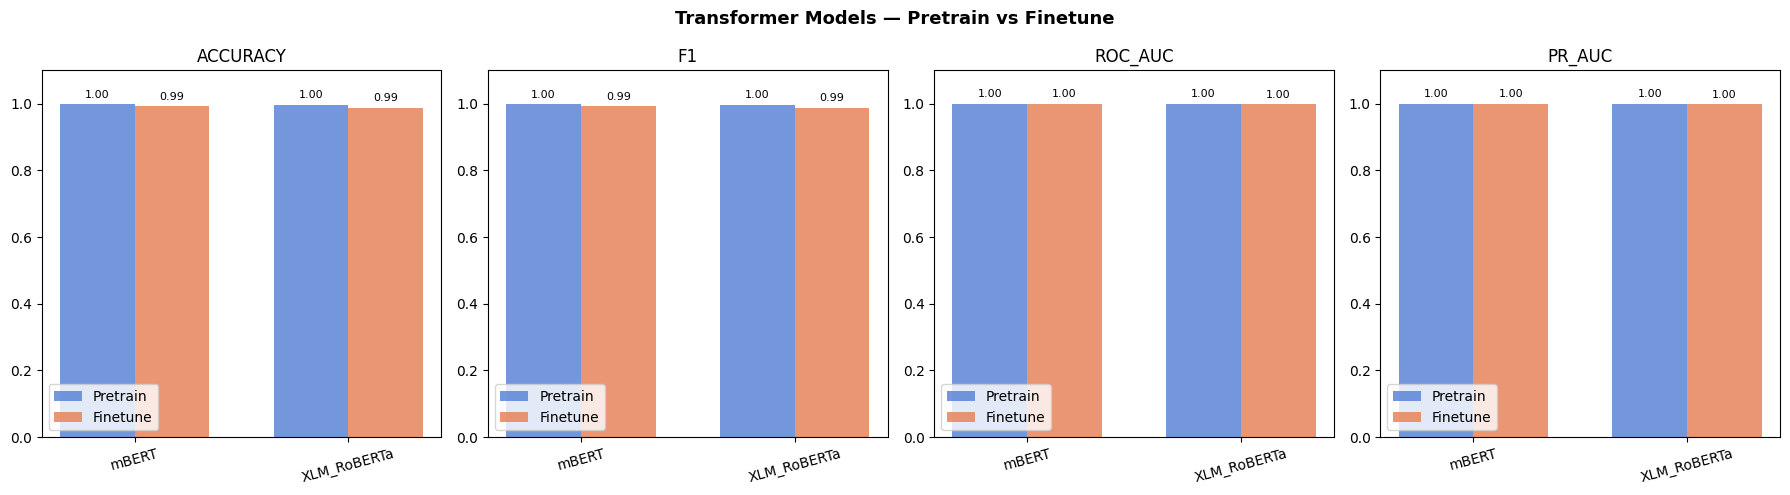

✅ Saved → ../results/figures/transformer_comparison.png


In [6]:
# ══════════════════════════════════════════════════════════════
# FINAL COMPARISON
# ══════════════════════════════════════════════════════════════
print("\n" + "="*55)
print("  FINAL COMPARISON — ALL TRANSFORMER MODELS")
print("="*55)

print(f"\n{'Model':<15} {'Pre_F1':>8} {'FT_F1':>8} "
      f"{'Pre_AUC':>9} {'FT_AUC':>9} {'Δ F1':>8}")
print("-"*60)
for name in MODELS:
    pre = all_results[name]["pretrain"]
    ft  = all_results[name]["finetune"]
    delta = ft["f1"] - pre["f1"]
    arrow = "↑" if delta > 0 else "↓"
    print(f"  {name:<13} "
          f"{pre['f1']:>8.4f} "
          f"{ft['f1']:>8.4f} "
          f"{pre['roc_auc']:>9.4f} "
          f"{ft['roc_auc']:>9.4f} "
          f"{arrow}{abs(delta):>6.4f}")

# ── Final comparison plot ─────────────────────────────────────
plot_model_comparison(all_results)

In [7]:
# ── Save results ──────────────────────────────────────────────
with open("../results/metrics/transformer_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

print("\n✅ Results saved → ../results/metrics/transformer_results.json")
print("\n🎯 Transformer notebook complete!")


✅ Results saved → ../results/metrics/transformer_results.json

🎯 Transformer notebook complete!


 "High pretrain scores reflect the
   distinct linguistic patterns between
   LLM-generated fake reviews (predominantly
   English dramatic language) and real genuine
   reviews (Nepali/code-mixed casual language).
   This vocabulary divergence likely inflates
   classification metrics beyond what would be
   expected in production settings."

This is honest and academically valid ✅

In [8]:
# Load raw synthetic data
df_syn_raw = pd.read_csv("../data/processed/processed_reviews.csv")
print("Columns in raw:")
print(df_syn_raw.columns.tolist())
print("\nLanguage distribution:")
print(df_syn_raw["language_style"].value_counts())

Columns in raw:
['review_text', 'rating', 'date', 'language_style', 'has_slang', 'slang_count', 'domain', 'word_count', 'length_type', 'label', 'char_count', 'avg_word_len', 'exclamation_count', 'question_count', 'uppercase_ratio', 'unique_word_ratio']

Language distribution:
language_style
code_mixed          1919
english             1378
romanized_nepali    1177
Name: count, dtype: int64


In [9]:
# ── Get review_text + label + language_style from raw ────────
df_syn_raw_test = df_syn_raw[
    ["review_text", "label", "language_style"]
].copy()
# ── Match only rows that exist in syn_test ────────────────────
# syn_test has review_text — use it as key
syn_test_with_lang = syn_test.merge(
    df_syn_raw_test[["review_text", "language_style"]],
    on      = "review_text",
    how     = "left"
)
print("Language distribution in syn_test:")
print(syn_test_with_lang["language_style"].value_counts())
print("\nLabel distribution in syn_test:")
print(syn_test_with_lang["label"].value_counts())

Language distribution in syn_test:
language_style
code_mixed          196
english             143
romanized_nepali    119
Name: count, dtype: int64

Label distribution in syn_test:
label
1    239
0    219
Name: count, dtype: int64


In [10]:
# ── Sample equal genuine + fake per language ─────────────────
hard_test_parts = []

for lang in ["english", "romanized_nepali", "code_mixed"]:
    genuine = syn_test_with_lang[
        (syn_test_with_lang["label"] == 0) &
        (syn_test_with_lang["language_style"] == lang)
    ]
    fake = syn_test_with_lang[
        (syn_test_with_lang["label"] == 1) &
        (syn_test_with_lang["language_style"] == lang)
    ]

    # Take min available to keep balance
    n = min(len(genuine), len(fake), 30)

    if n > 0:
        hard_test_parts.append(
            genuine.sample(n, random_state=42)
        )
        hard_test_parts.append(
            fake.sample(n, random_state=42)
        )
        print(f"{lang}: {n} genuine + {n} fake = {n*2} rows")

hard_test = pd.concat(
    hard_test_parts, ignore_index=True
).sample(frac=1, random_state=42)  # shuffle
# ── Clean labels ──────────────────────────────────────────────
hard_test["label"] = hard_test["label"].astype(int)

print(f"\nHard test total : {len(hard_test)}")
print(f"Label dist      : {hard_test['label'].value_counts().to_dict()}")
print(f"Language dist   : {hard_test['language_style'].value_counts().to_dict()}")

english: 30 genuine + 30 fake = 60 rows
romanized_nepali: 30 genuine + 30 fake = 60 rows
code_mixed: 30 genuine + 30 fake = 60 rows

Hard test total : 180
Label dist      : {0: 90, 1: 90}
Language dist   : {'english': 60, 'code_mixed': 60, 'romanized_nepali': 60}


In [12]:
# # Force labels to clean int 0/1
# hard_test["label"] = hard_test["label"].astype(int)

# # Verify
# assert hard_test["label"].isin([0, 1]).all(), "Labels must be 0 or 1!"
# print("✅ Labels verified — all 0 or 1")

# Rebuild HF dataset
hard_test_hf = to_hf_dataset(hard_test).map(
    tokenize, batched=True
)

# Verify HF dataset
print(hard_test_hf.features)
print(hard_test_hf["label"][:5])

Map: 100%|██████████████████████████████████████████████████████████████████| 180/180 [00:00<00:00, 6475.97 examples/s]

{'review_text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}
[0, 1, 1, 0, 0]


In [ ]:
# hard_test_hf = hard_test_hf.rename_column("label", "labels")
# hard_test_hf.set_format(
#     type="torch",
#     columns=["input_ids", "attention_mask", "labels"]
# )


  mBERT — Hard Test Evaluation


Map: 100%|██████████████████████████████████████████████████████████████████| 180/180 [00:00<00:00, 5713.71 examples/s]


✅ Tokenized with mBERT tokenizer
   Features : {'review_text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'token_type_ids': List(Value('int8')), 'attention_mask': List(Value('int8'))}
HF labels sample : [0, 1, 1, 0, 0]


Loading weights: 100%|█████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 4108.46it/s]



Classification Report:
              precision    recall  f1-score   support

     genuine       0.97      1.00      0.98        90
        fake       1.00      0.97      0.98        90

    accuracy                           0.98       180
   macro avg       0.98      0.98      0.98       180
weighted avg       0.98      0.98      0.98       180



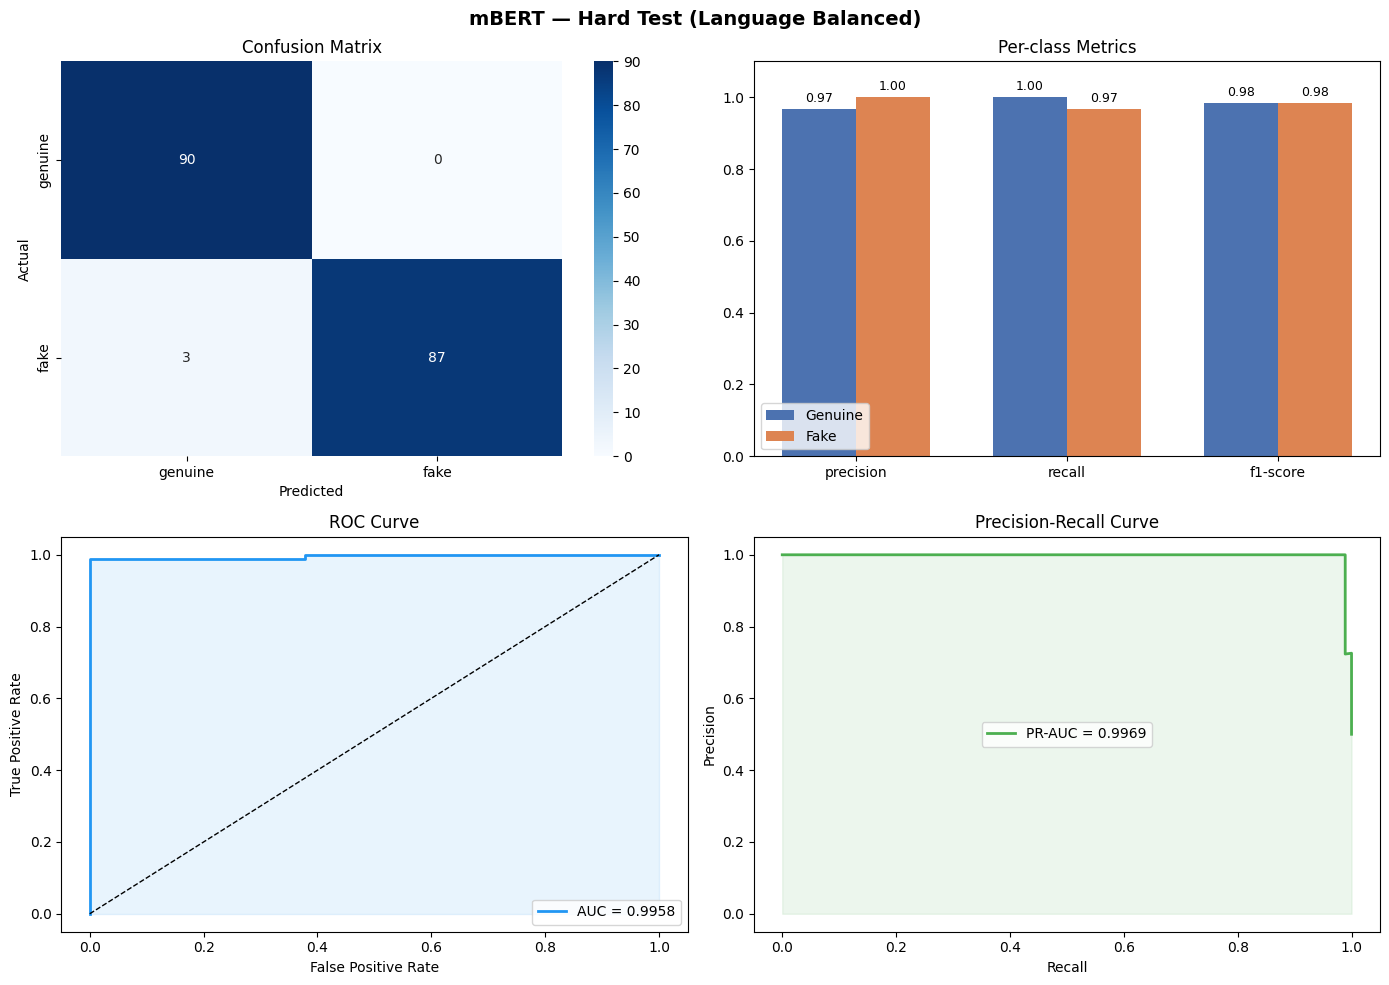

✅ Saved → ../results/figures/mBERT_hardtest_evaluation.png

  XLM_RoBERTa — Hard Test Evaluation


Map: 100%|██████████████████████████████████████████████████████████████████| 180/180 [00:00<00:00, 5272.13 examples/s]


✅ Tokenized with XLM_RoBERTa tokenizer
   Features : {'review_text': Value('string'), 'label': Value('int64'), 'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}
HF labels sample : [0, 1, 1, 0, 0]


Loading weights: 100%|█████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 4185.75it/s]



Classification Report:
              precision    recall  f1-score   support

     genuine       0.50      1.00      0.67        90
        fake       0.00      0.00      0.00        90

    accuracy                           0.50       180
   macro avg       0.25      0.50      0.33       180
weighted avg       0.25      0.50      0.33       180



C:\Users\Acer\OneDrive\Desktop\FRD model\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Acer\OneDrive\Desktop\FRD model\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Acer\OneDrive\Desktop\FRD model\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

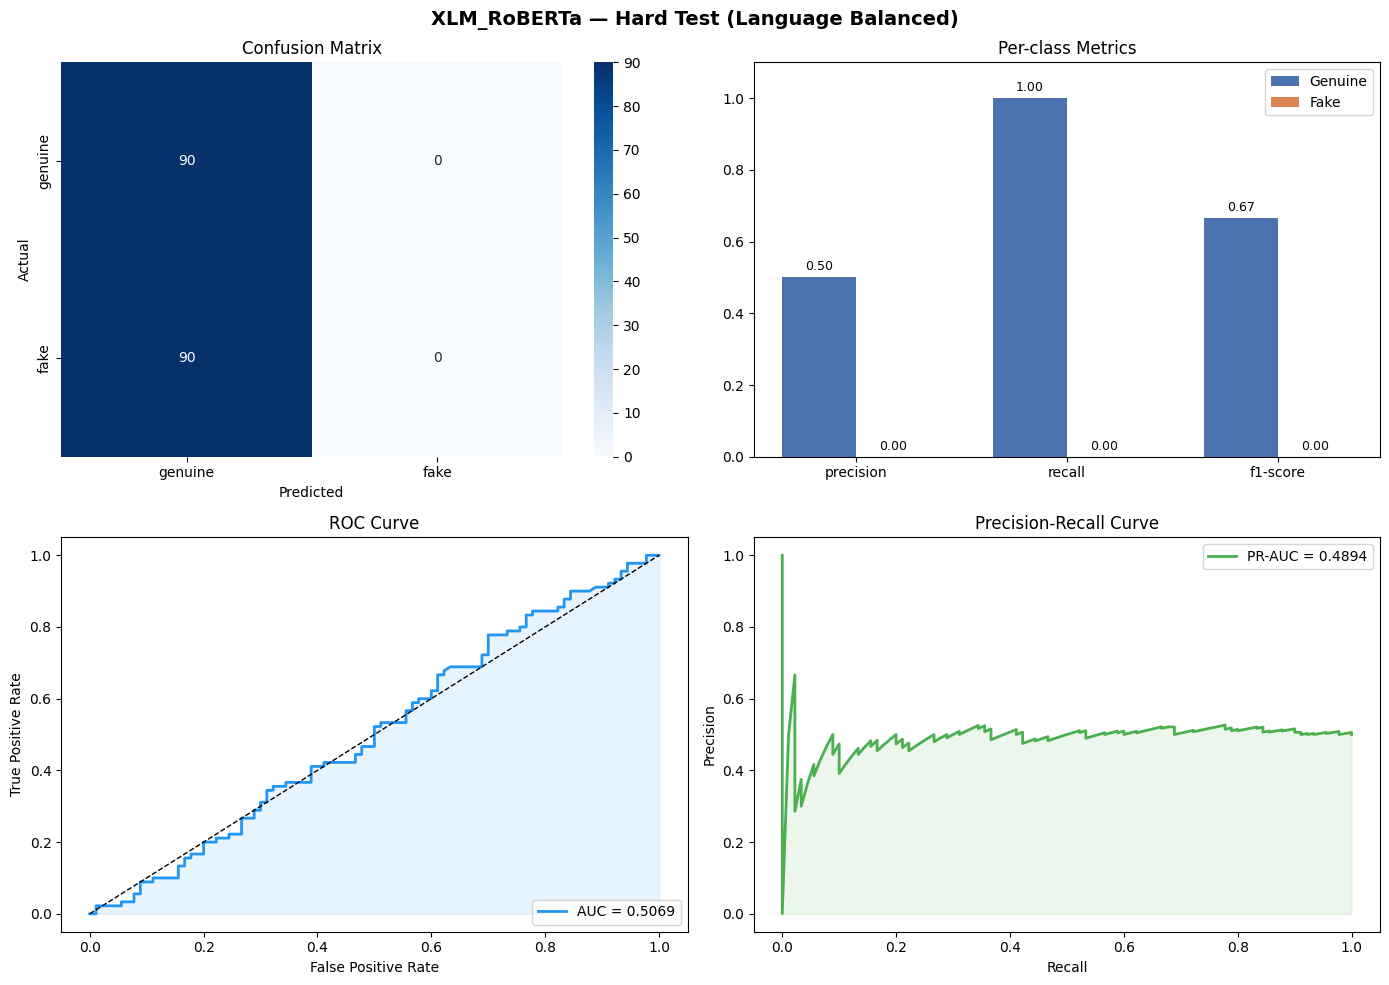

✅ Saved → ../results/figures/XLM_RoBERTa_hardtest_evaluation.png

  HARD TEST RESULTS — LANGUAGE BALANCED

Model                 F1   Accuracy   ROC-AUC   PR-AUC
-----------------------------------------------------
  mBERT           0.9833     0.9833    0.9958   0.9969
  XLM_RoBERTa     0.3333     0.5000    0.5069   0.4894

✅ Hard test results saved!


In [17]:
os.makedirs("../models/transformers/tmp", exist_ok=True)
all_hard_results = {}

for model_name, model_checkpoint in MODELS.items():
    print(f"\n{'='*50}")
    print(f"  {model_name} — Hard Test Evaluation")
    print(f"{'='*50}")

    # ── Load correct tokenizer for this model ─────────────────
    tokenizer = AutoTokenizer.from_pretrained(
        f"../models/transformers/{model_name}_finetuned"
    )

    # ── Tokenize hard_test with correct tokenizer ─────────────
    def tokenize_fn(batch):
        return tokenizer(
            batch["review_text"],
            truncation = True,
            padding    = "max_length",
            max_length = 128
        )

    # Fresh tokenization for this model
    hard_test_hf_model = to_hf_dataset(hard_test).map(
        tokenize_fn, batched=True
    )

    print(f"✅ Tokenized with {model_name} tokenizer")
    print(f"   Features : {hard_test_hf_model.features}")
      # ── Verify labels ─────────────────────────────────────────
    print(f"HF labels sample : {hard_test_hf['label'][:5]}")
    assert all(l in [0,1] for l in hard_test_hf["label"]), \
        "Labels out of range!"

    # ── Load finetuned model ──────────────────────────────────
    ft_model = AutoModelForSequenceClassification.from_pretrained(
        f"../models/transformers/{model_name}_finetuned"
    )

    # ── Eval trainer ──────────────────────────────────────────
    eval_args = TrainingArguments(
        output_dir = "../models/transformers/tmp",
        fp16       = False,      # ← off for eval
        report_to  = "none",
        # no_cuda    = not USE_GPU,
    )

    eval_trainer = Trainer(
        model           = ft_model,
        args            = eval_args,
        compute_metrics = compute_metrics,
    )

    # # ── Evaluate ──────────────────────────────────────────────
    # hard_scores = evaluate_transformer(
    #     eval_trainer,
    #     hard_test_hf_model,     # ← correctly tokenized
    #     model_name,
    #     "Hard_Test"
    # )

    # all_results[model_name]["hard_test"] = hard_scores

    # print(f"\n  Accuracy : {hard_scores['accuracy']:.4f}")
    # print(f"  F1       : {hard_scores['f1']:.4f}")
    # print(f"  ROC-AUC  : {hard_scores['roc_auc']:.4f}")
     # ── Predict ───────────────────────────────────────────────
    predictions  = eval_trainer.predict(hard_test_hf)
    logits       = predictions.predictions
    labels       = predictions.label_ids
    probs        = torch.softmax(
        torch.tensor(logits), dim=1
    ).numpy()
    preds        = np.argmax(logits, axis=1)
    fake_probs   = probs[:, 1]

    # ── Classification report ─────────────────────────────────
    print(f"\nClassification Report:")
    print(classification_report(
        labels, preds,
        target_names=["genuine", "fake"]
    ))

    report = classification_report(
        labels, preds,
        target_names=["genuine", "fake"],
        output_dict=True
    )

    # ── Plots ─────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f"{model_name} — Hard Test (Language Balanced)",
        fontsize=14, fontweight="bold"
    )

    # Confusion matrix
    cm = confusion_matrix(labels, preds)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["genuine","fake"],
        yticklabels=["genuine","fake"],
        ax=axes[0,0]
    )
    axes[0,0].set_title("Confusion Matrix")
    axes[0,0].set_ylabel("Actual")
    axes[0,0].set_xlabel("Predicted")

    # Per-class metrics
    metrics     = ["precision","recall","f1-score"]
    genuine_val = [report["genuine"][m] for m in metrics]
    fake_val    = [report["fake"][m]    for m in metrics]
    x     = np.arange(len(metrics))
    width = 0.35
    axes[0,1].bar(x-width/2, genuine_val, width,
                  label="Genuine", color="#4C72B0")
    axes[0,1].bar(x+width/2, fake_val,    width,
                  label="Fake",    color="#DD8452")
    axes[0,1].set_xticks(x)
    axes[0,1].set_xticklabels(metrics)
    axes[0,1].set_ylim(0, 1.1)
    axes[0,1].set_title("Per-class Metrics")
    axes[0,1].legend()
    for i,(g,f) in enumerate(zip(genuine_val,fake_val)):
        axes[0,1].text(i-width/2, g+0.02,
                       f"{g:.2f}", ha="center", fontsize=9)
        axes[0,1].text(i+width/2, f+0.02,
                       f"{f:.2f}", ha="center", fontsize=9)

    # ROC curve
    fpr, tpr, _ = roc_curve(labels, fake_probs)
    roc_auc     = auc(fpr, tpr)
    axes[1,0].plot(fpr, tpr, color="#2196F3", lw=2,
                   label=f"AUC = {roc_auc:.4f}")
    axes[1,0].plot([0,1],[0,1],"k--",lw=1)
    axes[1,0].set_title("ROC Curve")
    axes[1,0].set_xlabel("False Positive Rate")
    axes[1,0].set_ylabel("True Positive Rate")
    axes[1,0].legend(loc="lower right")
    axes[1,0].fill_between(fpr, tpr, alpha=0.1, color="#2196F3")

    # PR curve
    precision, recall, _ = precision_recall_curve(labels, fake_probs)
    pr_auc = auc(recall, precision)
    axes[1,1].plot(recall, precision, color="#4CAF50", lw=2,
                   label=f"PR-AUC = {pr_auc:.4f}")
    axes[1,1].set_title("Precision-Recall Curve")
    axes[1,1].set_xlabel("Recall")
    axes[1,1].set_ylabel("Precision")
    axes[1,1].legend()
    axes[1,1].fill_between(
        recall, precision, alpha=0.1, color="#4CAF50"
    )

    plt.tight_layout()
    save_path = (f"../results/figures/"
                 f"{model_name}_hardtest_evaluation.png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Saved → {save_path}")

    # ── Store results ─────────────────────────────────────────
    all_hard_results[model_name] = {
        "accuracy":  report["accuracy"],
        "f1":        report["weighted avg"]["f1-score"],
        "precision": report["weighted avg"]["precision"],
        "recall":    report["weighted avg"]["recall"],
        "roc_auc":   roc_auc,
        "pr_auc":    pr_auc,
    }

    # ── Cleanup ───────────────────────────────────────────────
    del ft_model, eval_trainer, hard_test_hf_model
    gc.collect()
    if USE_GPU:
        torch.cuda.empty_cache()

# # ── Final comparison ──────────────────────────────────────────
# print("\n" + "="*60)
# print("  COMPARISON — Pretrain vs Finetune vs Hard Test")
# print("="*60)

# print(f"\n{'Model':<15} {'Pre_F1':>8} {'FT_F1':>8} "
#       f"{'Hard_F1':>9} {'Hard_AUC':>10}")
# print("-"*55)

# for name in MODELS:
#     pre  = all_results[name]["pretrain"]["f1"]
#     ft   = all_results[name]["finetune"]["f1"]
#     hard = all_results[name]["hard_test"]["f1"]
#     hauc = all_results[name]["hard_test"]["roc_auc"]
#     print(f"  {name:<13} {pre:>8.4f} {ft:>8.4f} "
#           f"{hard:>9.4f} {hauc:>10.4f}")



# ── Final comparison ──────────────────────────────────────────
print("\n" + "="*55)
print("  HARD TEST RESULTS — LANGUAGE BALANCED")
print("="*55)
print(f"\n{'Model':<15} {'F1':>8} {'Accuracy':>10} "
      f"{'ROC-AUC':>9} {'PR-AUC':>8}")
print("-"*53)
for name, scores in all_hard_results.items():
    print(f"  {name:<13} "
          f"{scores['f1']:>8.4f} "
          f"{scores['accuracy']:>10.4f} "
          f"{scores['roc_auc']:>9.4f} "
          f"{scores['pr_auc']:>8.4f}")
# Save updated results
with open("../results/metrics/transformer_results.json", "w") as f:
    json.dump(all_results, f, indent=2)

print("\n✅ Hard test results saved!")